In [2]:
# ============================================================
# CELL 1 — Imports & Device
# ============================================================
import os
import glob
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import json

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ============================================================
# CELL 2 — Dataset Parser (your existing one, unchanged)
# ============================================================
def parse_plantvillage_dataset(data_dir):
    image_paths, species_labels, disease_labels = [], [], []
    species_to_idx, disease_to_idx = {}, {}

    for folder_name in os.listdir(data_dir):
        folder_path = os.path.join(data_dir, folder_name)
        if not os.path.isdir(folder_path):
            continue
        parts = folder_name.split('__')
        if len(parts) != 2:
            continue
        species_name, disease_name = parts[0], parts[1]

        if species_name not in species_to_idx:
            species_to_idx[species_name] = len(species_to_idx)
        if disease_name not in disease_to_idx:
            disease_to_idx[disease_name] = len(disease_to_idx)

        species_id = species_to_idx[species_name]
        disease_id = disease_to_idx[disease_name]

        for img_path in glob.glob(os.path.join(folder_path, "*.*")):
            image_paths.append(img_path)
            species_labels.append(species_id)
            disease_labels.append(disease_id)

    return image_paths, species_labels, disease_labels, species_to_idx, disease_to_idx

# ============================================================
# CELL 3 — Dataset Class
# ============================================================
class MultiTaskLeafDataset(Dataset):
    def __init__(self, image_paths, species_labels, disease_labels, transform=None):
        self.image_paths = image_paths
        self.species_labels = species_labels
        self.disease_labels = disease_labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        species = torch.tensor(self.species_labels[idx], dtype=torch.long)
        disease = torch.tensor(self.disease_labels[idx], dtype=torch.long)
        return image, species, disease

# ============================================================
# CELL 4 — Transforms (with augmentation for training)
# ============================================================
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# ============================================================
# CELL 5 — Load Data
# ============================================================
data_dir = r'D:\Program Files\whisper-finetune\data\plantvillage dataset\color'

image_paths, species_labels, disease_labels, species_map, disease_map = \
    parse_plantvillage_dataset(data_dir)

print(f"Found {len(species_map)} species and {len(disease_map)} diseases")
print(f"Total images: {len(image_paths)}")

# Save maps immediately (inverted: index -> name for server.py)
maps_to_save = {
    "species_map": {v: k for k, v in species_map.items()},
    "disease_map": {v: k for k, v in disease_map.items()}
}
with open("multitask_class_maps.json", "w") as f:
    json.dump(maps_to_save, f, indent=2)
print("Saved class maps.")

# Train/val split (80/20)
from sklearn.model_selection import train_test_split
train_paths, val_paths, train_sp, val_sp, train_dis, val_dis = train_test_split(
    image_paths, species_labels, disease_labels,
    test_size=0.2, random_state=42
)

train_data = MultiTaskLeafDataset(train_paths, train_sp, train_dis, transform=train_transforms)
val_data   = MultiTaskLeafDataset(val_paths,   val_sp,   val_dis,   transform=val_transforms)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True,  pin_memory=True)
val_loader   = DataLoader(val_data,   batch_size=64, shuffle=False, pin_memory=True)

# ============================================================
# CELL 6 — Model
# ============================================================
class MultiTaskLeafModel(nn.Module):
    def __init__(self, num_species, num_diseases):
        super().__init__()
        resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)  # ResNet50 > ResNet18
        num_features = resnet.fc.in_features
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])
        
        # Deeper heads for better specialization
        self.species_head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(num_features, 256),
            nn.ReLU(),
            nn.Linear(256, num_species)
        )
        self.disease_head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(num_features, 256),
            nn.ReLU(),
            nn.Linear(256, num_diseases)
        )

    def forward(self, x):
        features = self.backbone(x)
        features = torch.flatten(features, 1)
        return self.species_head(features), self.disease_head(features)

num_unique_species  = len(species_map)
num_unique_diseases = len(disease_map)

model = MultiTaskLeafModel(num_unique_species, num_unique_diseases).to(device)

# ============================================================
# CELL 6.5 — Compute Class Weights for Imbalanced Data
# ============================================================
from collections import Counter

# Count occurrences of each class in training set
species_counts = Counter(train_sp)
disease_counts = Counter(train_dis)

# Compute weights: rarer classes get higher weight
def compute_weights(counts, num_classes, device):
    total = sum(counts.values())
    weights = []
    for i in range(num_classes):
        count = counts.get(i, 1)  # avoid division by zero
        weights.append(total / (num_classes * count))
    return torch.FloatTensor(weights).to(device)

species_weights = compute_weights(species_counts, num_unique_species, device)
disease_weights = compute_weights(disease_counts, num_unique_diseases, device)

print("Species weights:", species_weights)
print("Disease weights:", disease_weights)

# ============================================================
# CELL 7 — Loss, Optimizer, Scheduler
# ============================================================
criterion_species = nn.CrossEntropyLoss(weight=species_weights)
criterion_disease = nn.CrossEntropyLoss(weight=disease_weights)

optimizer = optim.Adam(model.parameters(), lr=0.0005)  # lower LR

# Reduces LR by 0.5 if val loss doesn't improve for 3 epochs
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3, verbose=True
)

# ============================================================
# CELL 8 — Training Loop
# ============================================================
epochs = 25  # was 7
best_val_loss = float('inf')

for epoch in range(epochs):
    start_time = time.time()
    model.train()
    running_loss = 0.0
    correct_species = correct_disease = 0
    total = 0

    for inputs, labels_sp, labels_dis in train_loader:
        inputs     = inputs.to(device)
        labels_sp  = labels_sp.to(device)
        labels_dis = labels_dis.to(device)

        optimizer.zero_grad()

        # ✅ FIXED: model returns exactly 2 values
        out_sp, out_dis = model(inputs)

        loss_sp  = criterion_species(out_sp, labels_sp)
        loss_dis = criterion_disease(out_dis, labels_dis)
        loss = loss_sp + loss_dis

        loss.backward()
        optimizer.step()

        running_loss    += loss.item() * inputs.size(0)
        correct_species += (out_sp.argmax(1) == labels_sp).sum().item()
        correct_disease += (out_dis.argmax(1) == labels_dis).sum().item()
        total           += inputs.size(0)

    train_loss = running_loss / total
    train_acc_sp  = correct_species / total * 100
    train_acc_dis = correct_disease / total * 100

    # --- Validation ---
    model.eval()
    val_loss = 0.0
    val_correct_sp = val_correct_dis = 0
    val_total = 0

    with torch.no_grad():
        for inputs, labels_sp, labels_dis in val_loader:
            inputs     = inputs.to(device)
            labels_sp  = labels_sp.to(device)
            labels_dis = labels_dis.to(device)

            out_sp, out_dis = model(inputs)
            loss = criterion_species(out_sp, labels_sp) + criterion_disease(out_dis, labels_dis)

            val_loss       += loss.item() * inputs.size(0)
            val_correct_sp  += (out_sp.argmax(1) == labels_sp).sum().item()
            val_correct_dis += (out_dis.argmax(1) == labels_dis).sum().item()
            val_total       += inputs.size(0)

    val_epoch_loss = val_loss / val_total
    val_acc_sp  = val_correct_sp  / val_total * 100
    val_acc_dis = val_correct_dis / val_total * 100

    scheduler.step(val_epoch_loss)

    # Save best model
    if val_epoch_loss < best_val_loss:
        best_val_loss = val_epoch_loss
        torch.save(model.state_dict(), "multitask_leaf_specialist.pth")
        print(f"  ✅ Best model saved at epoch {epoch+1}")

    elapsed = time.time() - start_time
    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {train_loss:.4f} | Sp: {train_acc_sp:.1f}% Dis: {train_acc_dis:.1f}% | "
          f"Val Loss: {val_epoch_loss:.4f} | Sp: {val_acc_sp:.1f}% Dis: {val_acc_dis:.1f}% | "
          f"Time: {elapsed:.0f}s")

print("\nTraining Complete! Best model saved as multitask_leaf_specialist.pth")

Using device: cuda
Found 14 species and 21 diseases
Total images: 54305
Saved class maps.
Species weights: tensor([ 1.2319,  2.5946,  2.0674,  1.0095,  0.9513,  0.7048,  1.4474,  1.5531,
         1.7968, 10.4483,  0.7645,  2.1520,  2.4746,  0.2130], device='cuda:0')
Disease weights: tensor([4.1709, 1.4416, 9.2355, 0.1716, 0.9162, 5.0705, 2.1708, 2.5699, 1.8621,
        2.3944, 0.4699, 0.4756, 1.2987, 0.8860, 2.3218, 2.6763, 1.4631, 1.5578,
        1.8243, 7.0128, 0.4790], device='cuda:0')


KeyboardInterrupt: 

In [2]:
# ============================================================
# CELL 1 — Imports & Device
# ============================================================
import os
import glob
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import json

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ============================================================
# CELL 2 — Dataset Parser 
# ============================================================
def parse_plantvillage_dataset(data_dir):
    image_paths, species_labels, disease_labels = [], [], []
    species_to_idx, disease_to_idx = {}, {}

    for folder_name in os.listdir(data_dir):
        folder_path = os.path.join(data_dir, folder_name)
        if not os.path.isdir(folder_path):
            continue
        parts = folder_name.split('__')
        if len(parts) != 2:
            continue
        species_name, disease_name = parts[0], parts[1]

        if species_name not in species_to_idx:
            species_to_idx[species_name] = len(species_to_idx)
        if disease_name not in disease_to_idx:
            disease_to_idx[disease_name] = len(disease_to_idx)

        species_id = species_to_idx[species_name]
        disease_id = disease_to_idx[disease_name]

        for img_path in glob.glob(os.path.join(folder_path, "*.*")):
            image_paths.append(img_path)
            species_labels.append(species_id)
            disease_labels.append(disease_id)

    return image_paths, species_labels, disease_labels, species_to_idx, disease_to_idx

# ============================================================
# CELL 3 — Dataset Class
# ============================================================
class MultiTaskLeafDataset(Dataset):
    def __init__(self, image_paths, species_labels, disease_labels, transform=None):
        self.image_paths = image_paths
        self.species_labels = species_labels
        self.disease_labels = disease_labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        species = torch.tensor(self.species_labels[idx], dtype=torch.long)
        disease = torch.tensor(self.disease_labels[idx], dtype=torch.long)
        return image, species, disease

# ============================================================
# CELL 4 — Transforms (with augmentation for training)
# ============================================================
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# ============================================================
# CELL 5 — Load Data
# ============================================================
data_dir = r'D:\Program Files\whisper-finetune\data\plantvillage dataset\color'

image_paths, species_labels, disease_labels, species_map, disease_map = \
    parse_plantvillage_dataset(data_dir)

print(f"Found {len(species_map)} species and {len(disease_map)} diseases")
print(f"Total images: {len(image_paths)}")

# Save maps immediately (inverted: index -> name for server.py)
maps_to_save = {
    "species_map": {v: k for k, v in species_map.items()},
    "disease_map": {v: k for k, v in disease_map.items()}
}
with open("multitask_class_maps.json", "w") as f:
    json.dump(maps_to_save, f, indent=2)
print("Saved class maps.")

# Train/val split (80/20)
from sklearn.model_selection import train_test_split
train_paths, val_paths, train_sp, val_sp, train_dis, val_dis = train_test_split(
    image_paths, species_labels, disease_labels,
    test_size=0.2, random_state=42
)

train_data = MultiTaskLeafDataset(train_paths, train_sp, train_dis, transform=train_transforms)
val_data   = MultiTaskLeafDataset(val_paths,   val_sp,   val_dis,   transform=val_transforms)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True,  pin_memory=True)
val_loader   = DataLoader(val_data,   batch_size=64, shuffle=False, pin_memory=True)

# ============================================================
# CELL 6 — Model
# ============================================================
class MultiTaskLeafModel(nn.Module):
    def __init__(self, num_species, num_diseases):
        super().__init__()
        resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)  # ResNet50 > ResNet18
        num_features = resnet.fc.in_features
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])
        
        # Deeper heads for better specialization
        self.species_head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(num_features, 256),
            nn.ReLU(),
            nn.Linear(256, num_species)
        )
        self.disease_head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(num_features, 256),
            nn.ReLU(),
            nn.Linear(256, num_diseases)
        )

    def forward(self, x):
        features = self.backbone(x)
        features = torch.flatten(features, 1)
        return self.species_head(features), self.disease_head(features)

num_unique_species  = len(species_map)
num_unique_diseases = len(disease_map)

model = MultiTaskLeafModel(num_unique_species, num_unique_diseases).to(device)

# ============================================================
# CELL 6.5 — Compute Class Weights for Imbalanced Data
# ============================================================
from collections import Counter

# Count occurrences of each class in training set
species_counts = Counter(train_sp)
disease_counts = Counter(train_dis)

# Compute weights: rarer classes get higher weight
def compute_weights(counts, num_classes, device):
    total = sum(counts.values())
    weights = []
    for i in range(num_classes):
        count = counts.get(i, 1)  # avoid division by zero
        weights.append(total / (num_classes * count))
    return torch.FloatTensor(weights).to(device)

species_weights = compute_weights(species_counts, num_unique_species, device)
disease_weights = compute_weights(disease_counts, num_unique_diseases, device)

print("Species weights:", species_weights)
print("Disease weights:", disease_weights)

# ============================================================
# CELL 7 — Loss, Optimizer, Scheduler
# ============================================================
criterion_species = nn.CrossEntropyLoss(weight=species_weights)
criterion_disease = nn.CrossEntropyLoss(weight=disease_weights)

optimizer = optim.Adam(model.parameters(), lr=0.0005)  # lower LR

# Reduces LR by 0.5 if val loss doesn't improve for 3 epochs
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)


Using device: cuda
Found 14 species and 21 diseases
Total images: 54305
Saved class maps.
Species weights: tensor([ 1.2319,  2.5946,  2.0674,  1.0095,  0.9513,  0.7048,  1.4474,  1.5531,
         1.7968, 10.4483,  0.7645,  2.1520,  2.4746,  0.2130], device='cuda:0')
Disease weights: tensor([4.1709, 1.4416, 9.2355, 0.1716, 0.9162, 5.0705, 2.1708, 2.5699, 1.8621,
        2.3944, 0.4699, 0.4756, 1.2987, 0.8860, 2.3218, 2.6763, 1.4631, 1.5578,
        1.8243, 7.0128, 0.4790], device='cuda:0')


In [8]:
# ============================================================
# CELL 8 — Training Loop
# ============================================================
epochs = 7  # was 7
best_val_loss = float('inf')

for epoch in range(epochs):
    start_time = time.time()
    model.train()
    running_loss = 0.0
    correct_species = correct_disease = 0
    total = 0

    for batch_idx, (inputs, labels_sp, labels_dis) in enumerate(train_loader):
        inputs     = inputs.to(device)
        labels_sp  = labels_sp.to(device)
        labels_dis = labels_dis.to(device)

        optimizer.zero_grad()

        # ✅ FIXED: model returns exactly 2 values
        out_sp, out_dis = model(inputs)

        loss_sp  = criterion_species(out_sp, labels_sp)
        loss_dis = criterion_disease(out_dis, labels_dis)
        loss = loss_sp + loss_dis

        loss.backward()
        optimizer.step()

        running_loss    += loss.item() * inputs.size(0)
        correct_species += (out_sp.argmax(1) == labels_sp).sum().item()
        correct_disease += (out_dis.argmax(1) == labels_dis).sum().item()
        total           += inputs.size(0)

         # ✅ Print progress every 100 batches
        if (batch_idx + 1) % 100 == 0:
            batches_done = batch_idx + 1
            batches_total = len(train_loader)
            avg_loss = running_loss / total
            avg_sp   = correct_species / total * 100
            avg_dis  = correct_disease / total * 100
            print(f"  Epoch [{epoch+1}/{epochs}] "
                  f"Batch [{batches_done}/{batches_total}] "
                  f"Loss: {avg_loss:.4f} | "
                  f"Sp: {avg_sp:.1f}% | "
                  f"Dis: {avg_dis:.1f}%")

    train_loss = running_loss / total
    train_acc_sp  = correct_species / total * 100
    train_acc_dis = correct_disease / total * 100

    # --- Validation ---
    model.eval()
    val_loss = 0.0
    val_correct_sp = val_correct_dis = 0
    val_total = 0

    with torch.no_grad():
        for inputs, labels_sp, labels_dis in val_loader:
            inputs     = inputs.to(device)
            labels_sp  = labels_sp.to(device)
            labels_dis = labels_dis.to(device)

            out_sp, out_dis = model(inputs)
            loss = criterion_species(out_sp, labels_sp) + criterion_disease(out_dis, labels_dis)

            val_loss       += loss.item() * inputs.size(0)
            val_correct_sp  += (out_sp.argmax(1) == labels_sp).sum().item()
            val_correct_dis += (out_dis.argmax(1) == labels_dis).sum().item()
            val_total       += inputs.size(0)

    val_epoch_loss = val_loss / val_total
    val_acc_sp  = val_correct_sp  / val_total * 100
    val_acc_dis = val_correct_dis / val_total * 100

    scheduler.step(val_epoch_loss)

    # Save best model
    if val_epoch_loss < best_val_loss:
        best_val_loss = val_epoch_loss
        torch.save(model.state_dict(), "multitask_leaf_specialist.pth")
        print(f"  ✅ Best model saved at epoch {epoch+1}")

    elapsed = time.time() - start_time
    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {train_loss:.4f} | Sp: {train_acc_sp:.1f}% Dis: {train_acc_dis:.1f}% | "
          f"Val Loss: {val_epoch_loss:.4f} | Sp: {val_acc_sp:.1f}% Dis: {val_acc_dis:.1f}% | "
          f"Time: {elapsed:.0f}s")

print("\nTraining Complete! Best model saved as multitask_leaf_specialist.pth")

  Epoch [1/7] Batch [100/679] Loss: 0.1549 | Sp: 98.6% | Dis: 97.4%
  Epoch [1/7] Batch [200/679] Loss: 0.1414 | Sp: 98.4% | Dis: 97.2%
  Epoch [1/7] Batch [300/679] Loss: 0.1480 | Sp: 98.5% | Dis: 97.1%
  Epoch [1/7] Batch [400/679] Loss: 0.1528 | Sp: 98.4% | Dis: 97.1%
  Epoch [1/7] Batch [500/679] Loss: 0.1446 | Sp: 98.4% | Dis: 97.2%
  Epoch [1/7] Batch [600/679] Loss: 0.1355 | Sp: 98.6% | Dis: 97.3%
  ✅ Best model saved at epoch 1
Epoch [1/7] Train Loss: 0.1297 | Sp: 98.7% Dis: 97.4% | Val Loss: 0.2162 | Sp: 98.7% Dis: 97.3% | Time: 2438s
  Epoch [2/7] Batch [100/679] Loss: 0.0908 | Sp: 99.0% | Dis: 97.9%
  Epoch [2/7] Batch [200/679] Loss: 0.0869 | Sp: 99.0% | Dis: 98.1%
  Epoch [2/7] Batch [300/679] Loss: 0.0925 | Sp: 98.9% | Dis: 98.1%
  Epoch [2/7] Batch [400/679] Loss: 0.0885 | Sp: 99.0% | Dis: 98.1%
  Epoch [2/7] Batch [500/679] Loss: 0.0846 | Sp: 99.1% | Dis: 98.1%
  Epoch [2/7] Batch [600/679] Loss: 0.0872 | Sp: 99.1% | Dis: 98.1%
  ✅ Best model saved at epoch 2
Epoch [2/7

Loaded 14 species and 21 diseases


C:\Users\HP\AppData\Local\Temp\ipykernel_38072\3530712929.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("multitask_leaf_specialist.pt

Model loaded successfully!


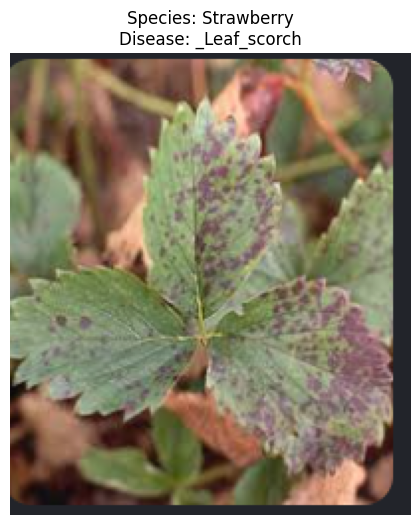


🌿 SPECIES PREDICTIONS:
  1. Strawberry                     100.0%
  2. Apple                          0.0%
  3. Potato                         0.0%

🦠 DISEASE PREDICTIONS:
  1. _Leaf_scorch                             100.0%
  2. _Esca_(Black_Measles)                    0.0%
  3. _Black_rot                               0.0%


In [3]:
# ============================================================
# CELL 9 — Load & Test Model in VS Code
# ============================================================
import torch
import json
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

# 1. Load class maps
with open("multitask_class_maps.json", "r") as f:
    loaded_maps = json.load(f)

# Maps are already index->name (we saved them that way in CELL 5)
species_map = {str(k): v for k, v in loaded_maps["species_map"].items()}
disease_map = {str(k): v for k, v in loaded_maps["disease_map"].items()}

print(f"Loaded {len(species_map)} species and {len(disease_map)} diseases")

# 2. Load model
num_species  = len(species_map)
num_diseases = len(disease_map)

model = MultiTaskLeafModel(num_species, num_diseases)
model.load_state_dict(torch.load("multitask_leaf_specialist.pth", map_location=device))
model.to(device)
model.eval()
print("Model loaded successfully!")

# 3. Define prediction function
def predict_leaf(image_path):
    # Load and preprocess image
    image = Image.open(image_path).convert("RGB")
    
    transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])
    
    input_tensor = transform(image).unsqueeze(0).to(device)
    
    with torch.no_grad():
        sp_out, dis_out = model(input_tensor)
    
    # Get top 3 predictions for both heads
    sp_probs  = torch.softmax(sp_out,  dim=1)[0]
    dis_probs = torch.softmax(dis_out, dim=1)[0]
    
    top3_sp  = torch.topk(sp_probs,  3)
    top3_dis = torch.topk(dis_probs, 3)
    
    # Display image
    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.axis('off')
    plt.title(f"Species: {species_map[str(top3_sp.indices[0].item())]}\n"
              f"Disease: {disease_map[str(top3_dis.indices[0].item())]}")
    plt.show()
    
    # Print detailed results
    print("\n🌿 SPECIES PREDICTIONS:")
    for i in range(3):
        idx  = top3_sp.indices[i].item()
        prob = top3_sp.values[i].item() * 100
        print(f"  {i+1}. {species_map[str(idx)]:<30} {prob:.1f}%")
    
    print("\n🦠 DISEASE PREDICTIONS:")
    for i in range(3):
        idx  = top3_dis.indices[i].item()
        prob = top3_dis.values[i].item() * 100
        print(f"  {i+1}. {disease_map[str(idx)]:<40} {prob:.1f}%")

# 4. Test on your images
# Change this path to any leaf image you want to test
predict_leaf(r"D:\Program Files\whisper-finetune\str.png")

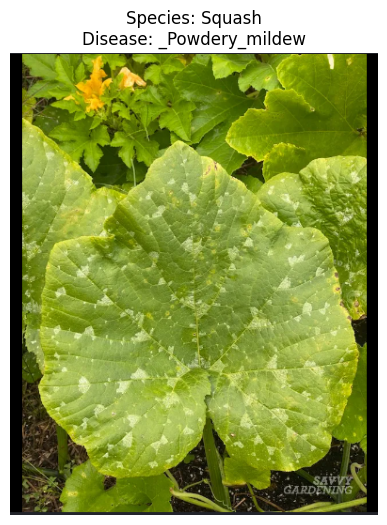


🌿 SPECIES PREDICTIONS:
  1. Squash                         99.7%
  2. Potato                         0.2%
  3. Cherry_(including_sour)        0.1%

🦠 DISEASE PREDICTIONS:
  1. _Powdery_mildew                          99.9%
  2. _Early_blight                            0.1%
  3. _Bacterial_spot                          0.0%


In [3]:
# 4. Test on your images
# Change this path to any leaf image you want to test
predict_leaf(r"D:\Program Files\whisper-finetune\ss2.png")